# Using scEve to improve clustering

In [1]:
# Import libraries
import warnings 
warnings.simplefilter('ignore')

import scanpy as sc
import scparadise
import muon as mu
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

sc.set_figure_params(dpi = 100, dpi_save = 300)

## Recommendations about dataset 
All models were trained on data normalized using the shifted logarithm method. <br>
For optimal performance, we recommend applying the same normalization method to your data before using the models:

```python
sc.pp.normalize_total(adata, target_sum=None)
sc.pp.log1p(adata)
```

Here, we used a multimodal object to demonstrate that the scEve model can improve data clustering in a manner similar to the observed protein.

In [2]:
# Load example data from 10x Genomics
url = "https://cf.10xgenomics.com/samples/cell-exp/6.0.0/10k_PBMCs_TotalSeq_B_3p/10k_PBMCs_TotalSeq_B_3p_filtered_feature_bc_matrix.h5"
mdata = mu.read_10x_h5("dataset.h5", backup_url = url)
adata_adt = mdata.mod['prot'].copy()
adata = mdata.mod['rna'].copy()
adata.var_names_make_unique()
del mdata

A unimodal scRNA-seq dataset can be loaded using the standard Scanpy functions shown below.

In [3]:
# Create/Load AnnData
# adata = sc.read_10x_h5("filtered_feature_bc_matrix.h5")
# adata = sc.read_h5ad('adata.h5ad')

## Gene expression data processing

In [4]:
# mitochondrial genes, "MT-" for human, "Mt-" for mouse
adata.var["mt"] = adata.var_names.str.startswith("MT-")
# ribosomal genes
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
# hemoglobin genes
adata.var["hb"] = adata.var_names.str.contains("^HB[^(P)]")

In [5]:
sc.pp.calculate_qc_metrics(
    adata, qc_vars=["mt", "ribo", "hb"], inplace=True, log1p=True
)

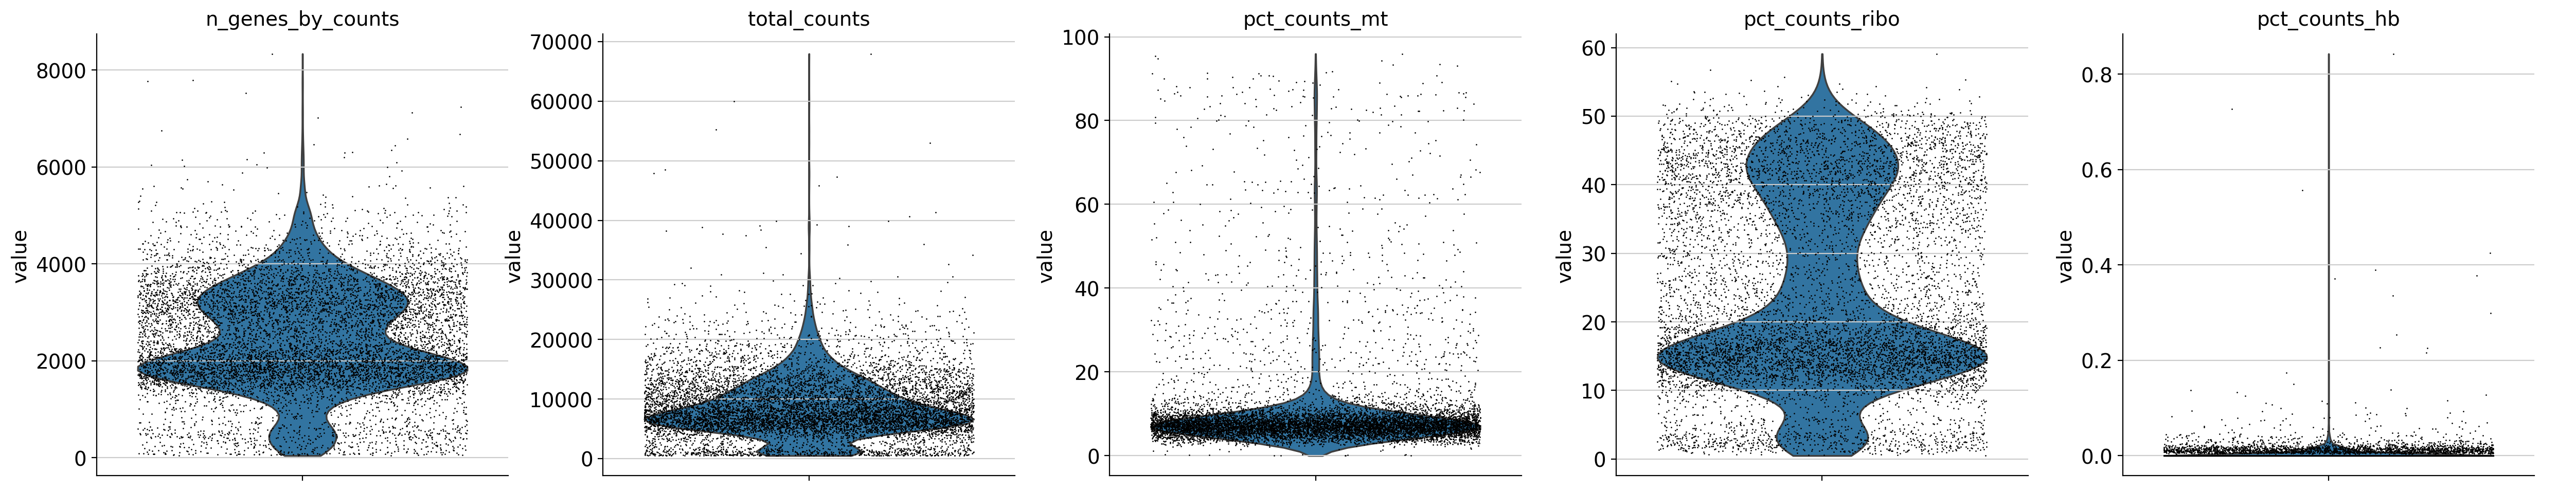

In [6]:
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt", 'pct_counts_ribo', 'pct_counts_hb'],
    jitter=0.4, 
    multi_panel=True,
)

In [7]:
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)

In [8]:
# Detect doublets
sc.pp.scrublet(adata)

In [9]:
# Remove doublets + other QC metrics
adata = adata[adata.obs['predicted_doublet'] == False]
sc.pp.filter_cells(adata, max_genes = 5000)
adata = adata[adata.obs['pct_counts_mt'] < 20]

## Normalization, HVG, neighbors, PCA, UMAP of RNA data

In [10]:
# Saving count data
adata.layers["counts"] = adata.X.copy()
# Normalization
sc.pp.normalize_total(adata, target_sum=None)
sc.pp.log1p(adata)
# HVG
sc.pp.highly_variable_genes(adata, n_top_genes=1200)
# PCA
sc.tl.pca(adata)
# Nearest neighbors analysis
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=15)
# UMAP
sc.tl.umap(adata, random_state=1)
# Clusterization
sc.tl.leiden(adata, resolution=0.5, key_added='leiden_0.5')

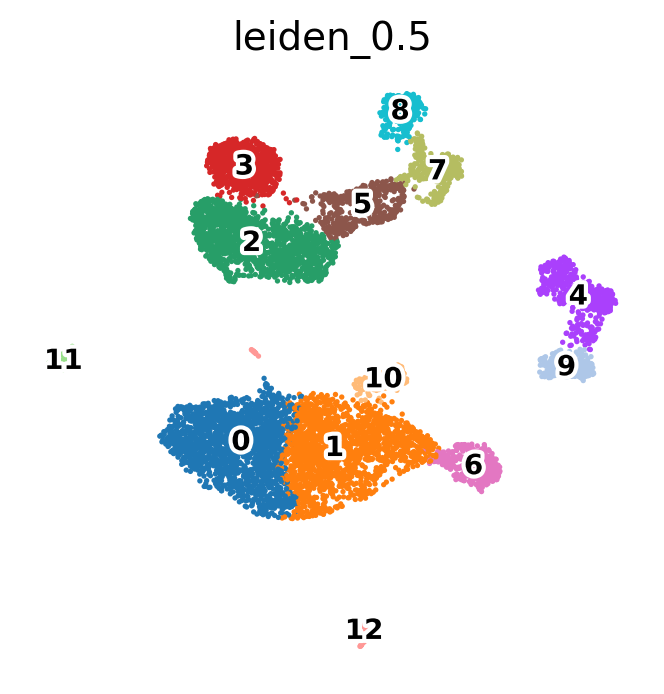

In [11]:
# Visualise clustering
sc.pl.umap(
    adata, 
    color = [
        'leiden_0.5'
    ],
    frameon = False,
    legend_loc = 'on data',
    legend_fontsize = 10,
    legend_fontoutline = 3
)

## Visualization of NK and T cell scores

To demonstrate the functionality of the scEve model, we use the classic problem of separating transcriptomically similar NK and T cells (specifically CD8+ cytotoxic T cells). <br> 
The second classic problem is the separation of CD4+ and CD8+ T cell subtypes (effector and memory cells), as well as other types of T cells. <br>
Below are the T and NK scores calculated based on the marker genes of these cell types.

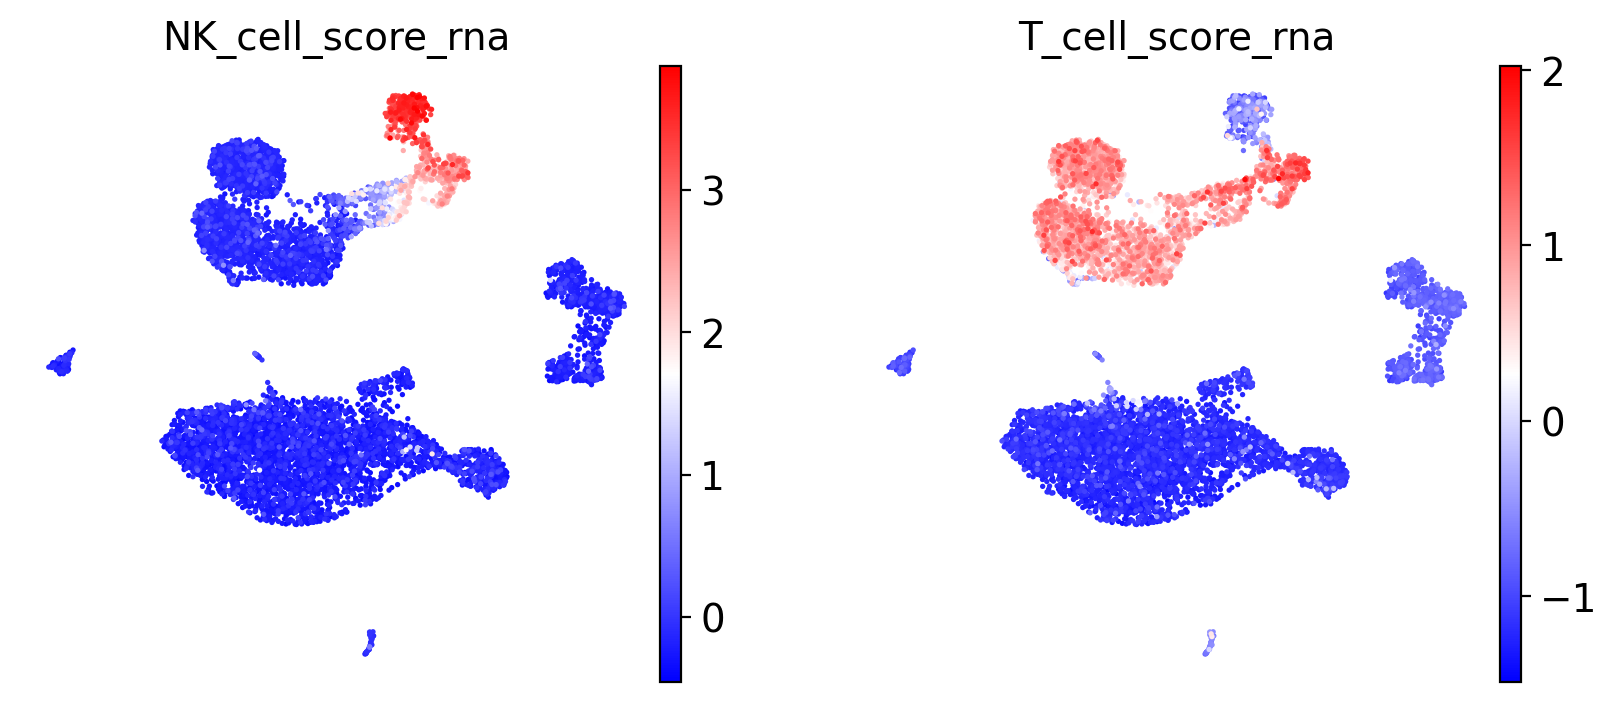

In [12]:
# Make NK cell score based on RNA expression
score_1 = 'NK_cell_score_rna'
markers = ['GNLY', 'NKG7', 'KLRF1']
sc.tl.score_genes(adata, markers, score_name=score_1)

# Make T cell score based on RNA expression
score_2 = 'T_cell_score_rna'
markers = ['CD3E', 'CD3G', 'CD3D']
sc.tl.score_genes(adata, markers, score_name=score_2)

# Visualize scores
sc.pl.umap(
    adata, 
    color = [score_1, 
             score_2
            ], 
    cmap = "bwr", 
    frameon = False,
    ncols = 2
)

(1.7856135073478991, 0.5497280700433537)

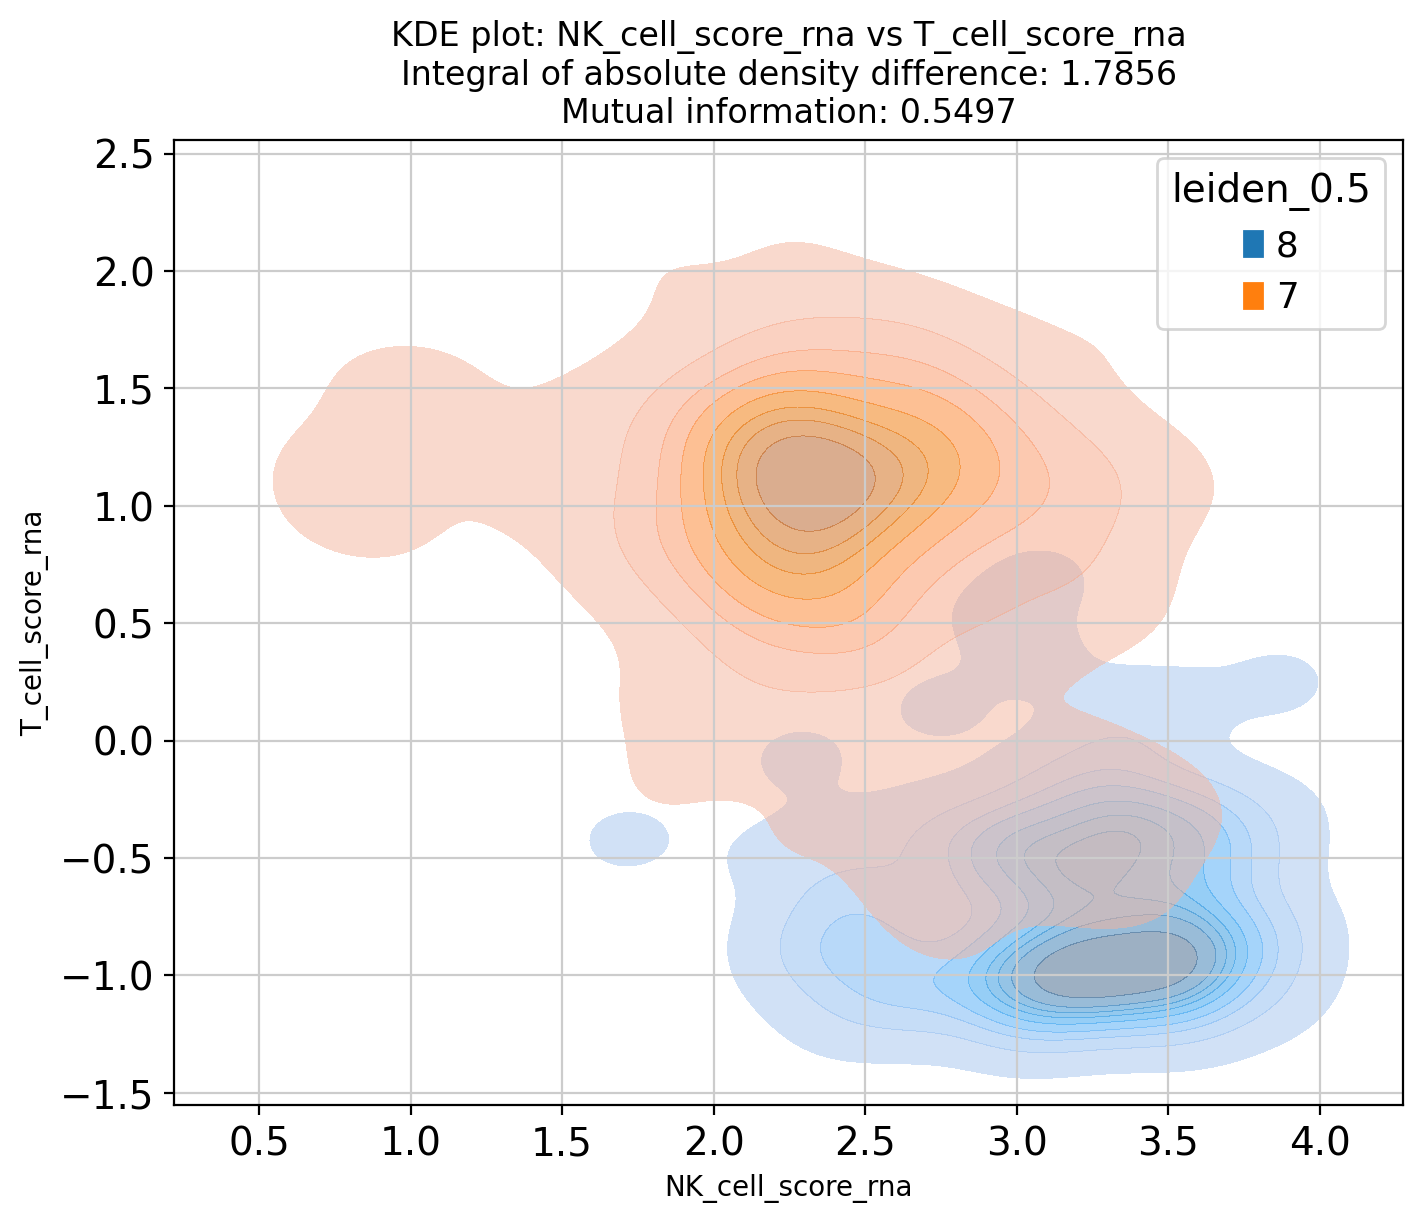

In [13]:
# Calculate Integral of absolute density difference and Mutual information
scparadise.scnoah.clust_diff(
    adata,
    groupby = 'leiden_0.5',
    group1 = '8',
    group2 = '7',
    score1 = 'NK_cell_score_rna',
    score2 = 'T_cell_score_rna'
)

Using RNA data, it is not possible to clearly define the cell type of cluster 6 (they can be either NK cells or T cells). <br>

The KDE plot also shows an overlap between 6 and 9 clusters based on NK and T scores calculated using RNA data. 

## Observed ADT preprocessing

In [14]:
adata_adt = adata_adt[adata.obs_names]
adata_adt.obsm['X_umap'] = adata.obsm['X_umap']

In [15]:
mu.prot.pp.clr(adata_adt)

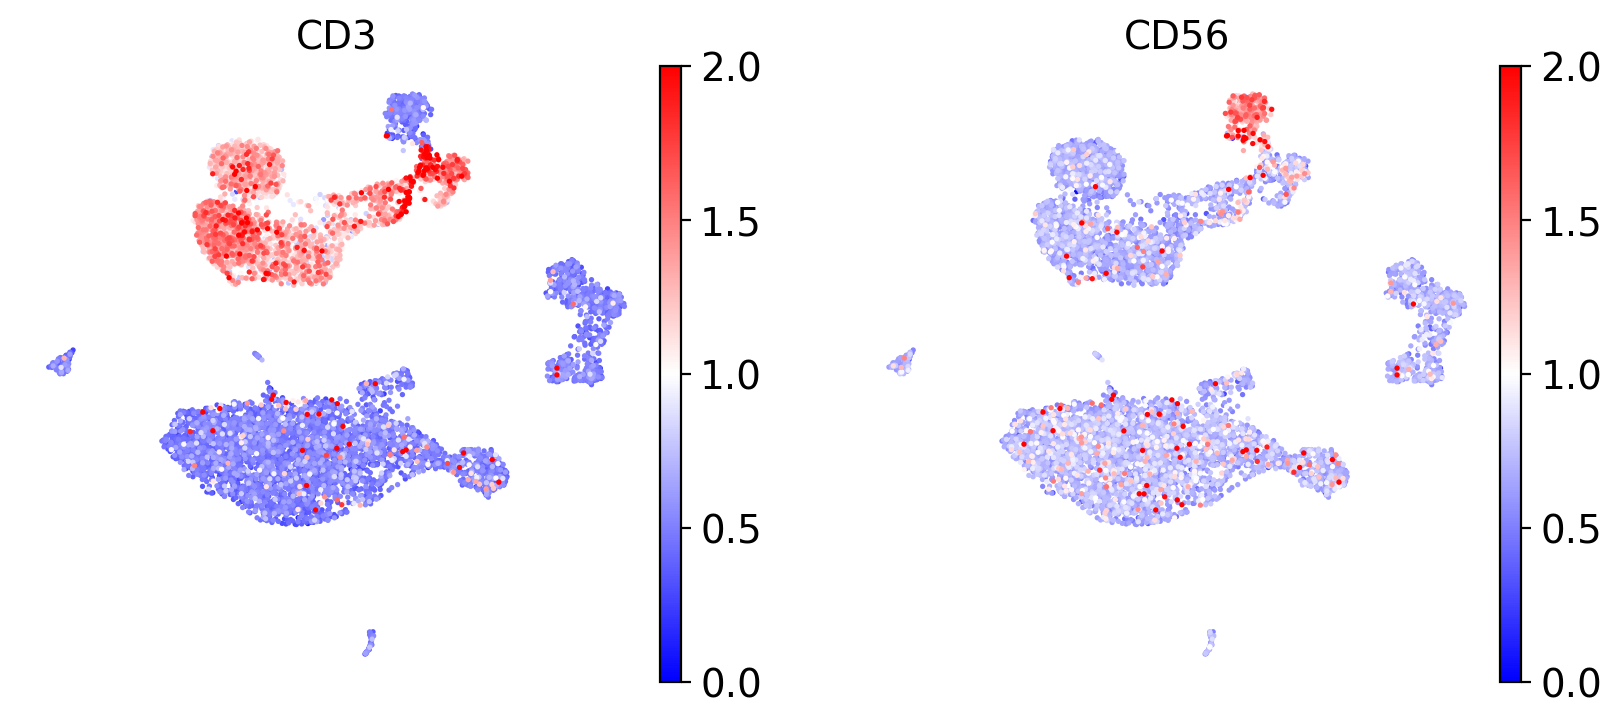

In [16]:
# Visualise CD3 and CD56
# CD3 - T cell marker
# CD56 - NK cell marker
sc.pl.umap(
    adata_adt, 
    color = [
        'CD3',
        'CD56'
    ],
    frameon = False,
    cmap = 'bwr',
    ncols = 2,
    vmax = 2.0
)

Using the observed proteins, a clear boundary can be seen between NK cells and T cells.

## scParadise prediction (scEve + scAdam)

To clearly differentiate cell types, you can add a new modality (abundance of surface proteins) using scEve models. <br> 
You can also use scAdam models to predict cell types.

In [17]:
# Available models for cell type annotation
df_eve = scparadise.sceve.available_models(query = 'PBMC')
df_eve

,Model name,Tissue/Organ,Species,Description,Suspension,RMSE,MAE,Number of Proteins
0,Human_PBMC_3p,blood,human,Peripheral blood mononuclear cells of healthy ...,cells,0.305,0.226,224
1,Human_PBMC_5p,blood,human,Peripheral blood mononuclear cells of healthy ...,cells,0.308,0.225,54


In [18]:
# Download model for cell type prediction
scparadise.sceve.download_model(
    model_name = 'Human_PBMC_3p', 
    save_path = ''
)

In [19]:
# Predict cell types using trained scEve model
mdata = scparadise.sceve.predict(
    adata, 
    path_model = 'Human_PBMC_3p_scEve',
    return_mdata = True
)

Feature prediction using the 2nd version of the scEve model
scEve model loaded from Human_PBMC_3p_scEve
Feature alignment:
Model features: 2000
New data features: 22189
Matched features: 1833 (91.7%)


Predicting: 100%|███████████████████████████████████████████████████████████████████████████████████████████████| 32/32 [00:00<00:00, 202.22it/s]


In [20]:
# Available models for cell type annotation
df_adam = scparadise.scadam.available_models(query = 'PBMC')
df_adam

,Model name,Tissue/Organ,Species,Description,Suspension,Accuracy,Balanced Accuracy,Number of Levels
0,Human_PBMC,blood,human,Peripheral blood mononuclear cells of healthy ...,cells,0.979,0.979,3


In [21]:
scparadise.scadam.download_model(
    model_name = 'Human_PBMC', 
    save_path = ''
)

In [22]:
mdata.mod['rna'] = scparadise.scadam.predict(
    mdata.mod['rna'], 
    path_model = 'Human_PBMC_scAdam'
)
mdata.update()

Cell type annotation using the 2nd version of the scAdam model
scAdam model with unknown detector loaded from Human_PBMC_scAdam
Gene alignment:
  Model features: 947
  Matched features: 936 (98.8%)


Predicting: 100%|███████████████████████████████████████████████████████████████████████████████████████████████| 32/32 [00:00<00:00, 141.22it/s]

Added cell type column: pred_celltype_l1
Added probabilities column: pred_celltype_l1_probability
Added cell type column: pred_celltype_l2
Added probabilities column: pred_celltype_l2_probability
Added cell type column: pred_celltype_l3
Added probabilities column: pred_celltype_l3_probability


## Clusterization and UMAP using imputed adt (abundance of surface proteins)

Next, we recommend using only highly variable proteins for PCA calculation. Among the proteins, there are also antibodies that poorly bound to cells in the training dataset.

In [23]:
sc.pp.highly_variable_genes(
    mdata.mod['adt'],
    n_top_genes=100,
    subset=False
)

In [24]:
# PCA using only highly variable proteins
sc.tl.pca(mdata.mod['adt'], use_highly_variable = True)

In [25]:
# Concatenate PCA from rna and imputed adt
mdata.obsm["X_pca_concat"] = np.hstack([mdata.mod["rna"].obsm["X_pca"][:, :15], mdata.mod["adt"].obsm["X_pca"][:, :15]])
mdata.update()

In [26]:
# Nearest neighbors analysis
sc.pp.neighbors(mdata, n_neighbors = 10, n_pcs = 30, use_rep = "X_pca_concat")
# UMAP
sc.tl.umap(mdata, random_state = 123)
# Clusterization
sc.tl.leiden(mdata, resolution = 0.5, key_added='leiden_0.5')

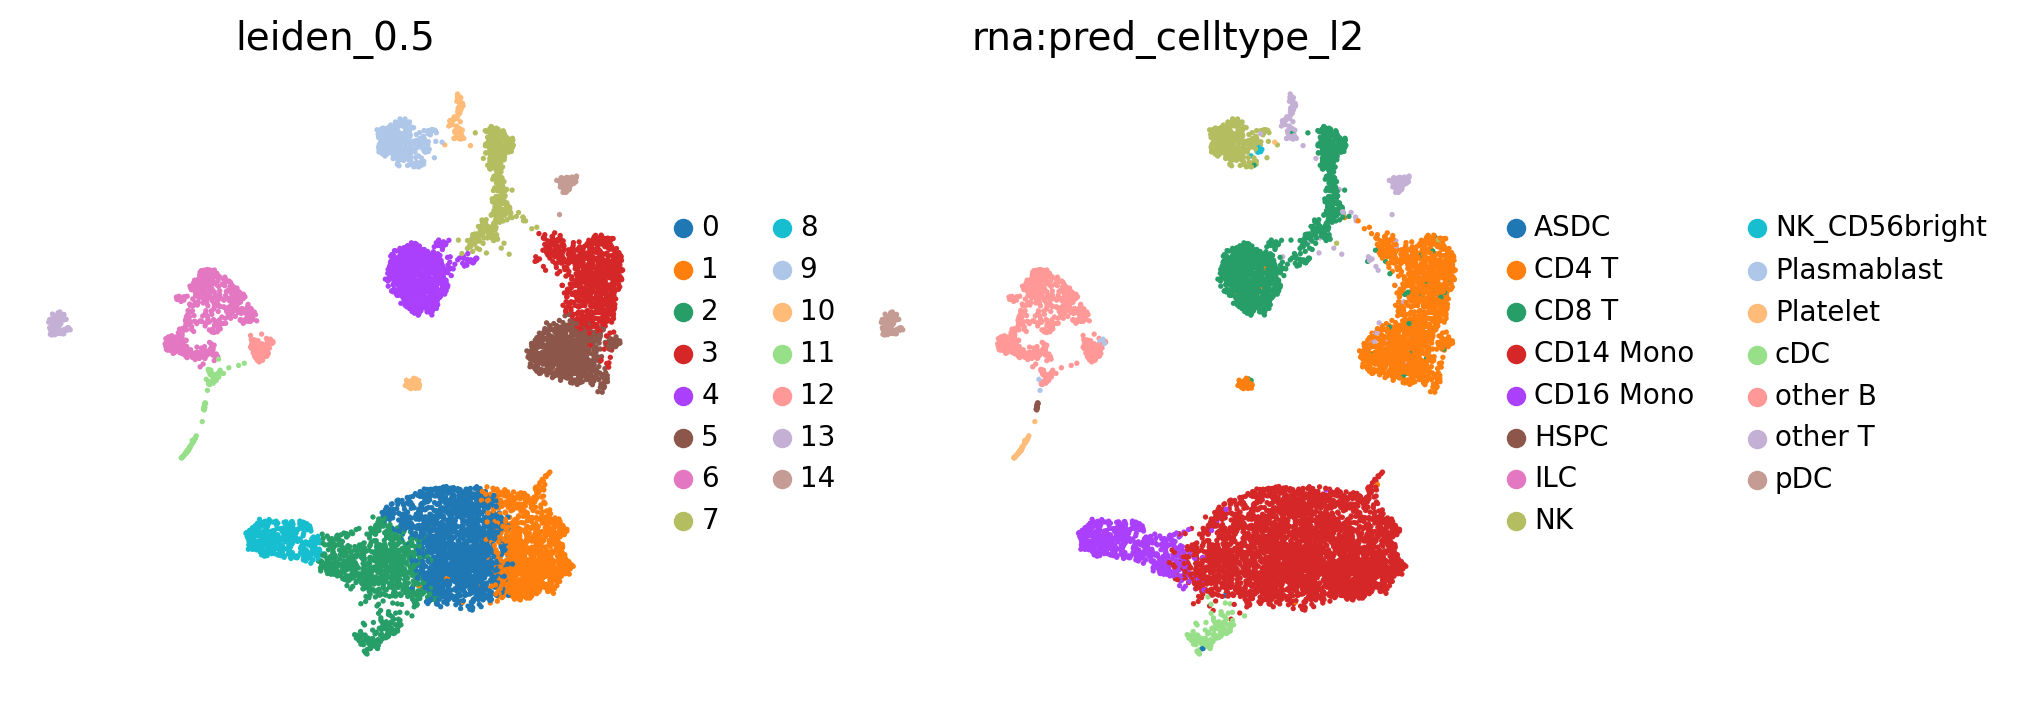

In [27]:
# Visualise clusterization on UMAP calculated using rna and imputed adt PCA
mu.pl.umap(
    mdata, 
    color = [
        'leiden_0.5',
        'rna:pred_celltype_l2'
    ],
    frameon = False,
    legend_loc = 'right margin',
    legend_fontsize = 10,
    wspace = 0.2
)

scEve surface protein prediction allows for a clear separation of T and NK cell subtypes, as seen in the resulting clustering and UMAP.

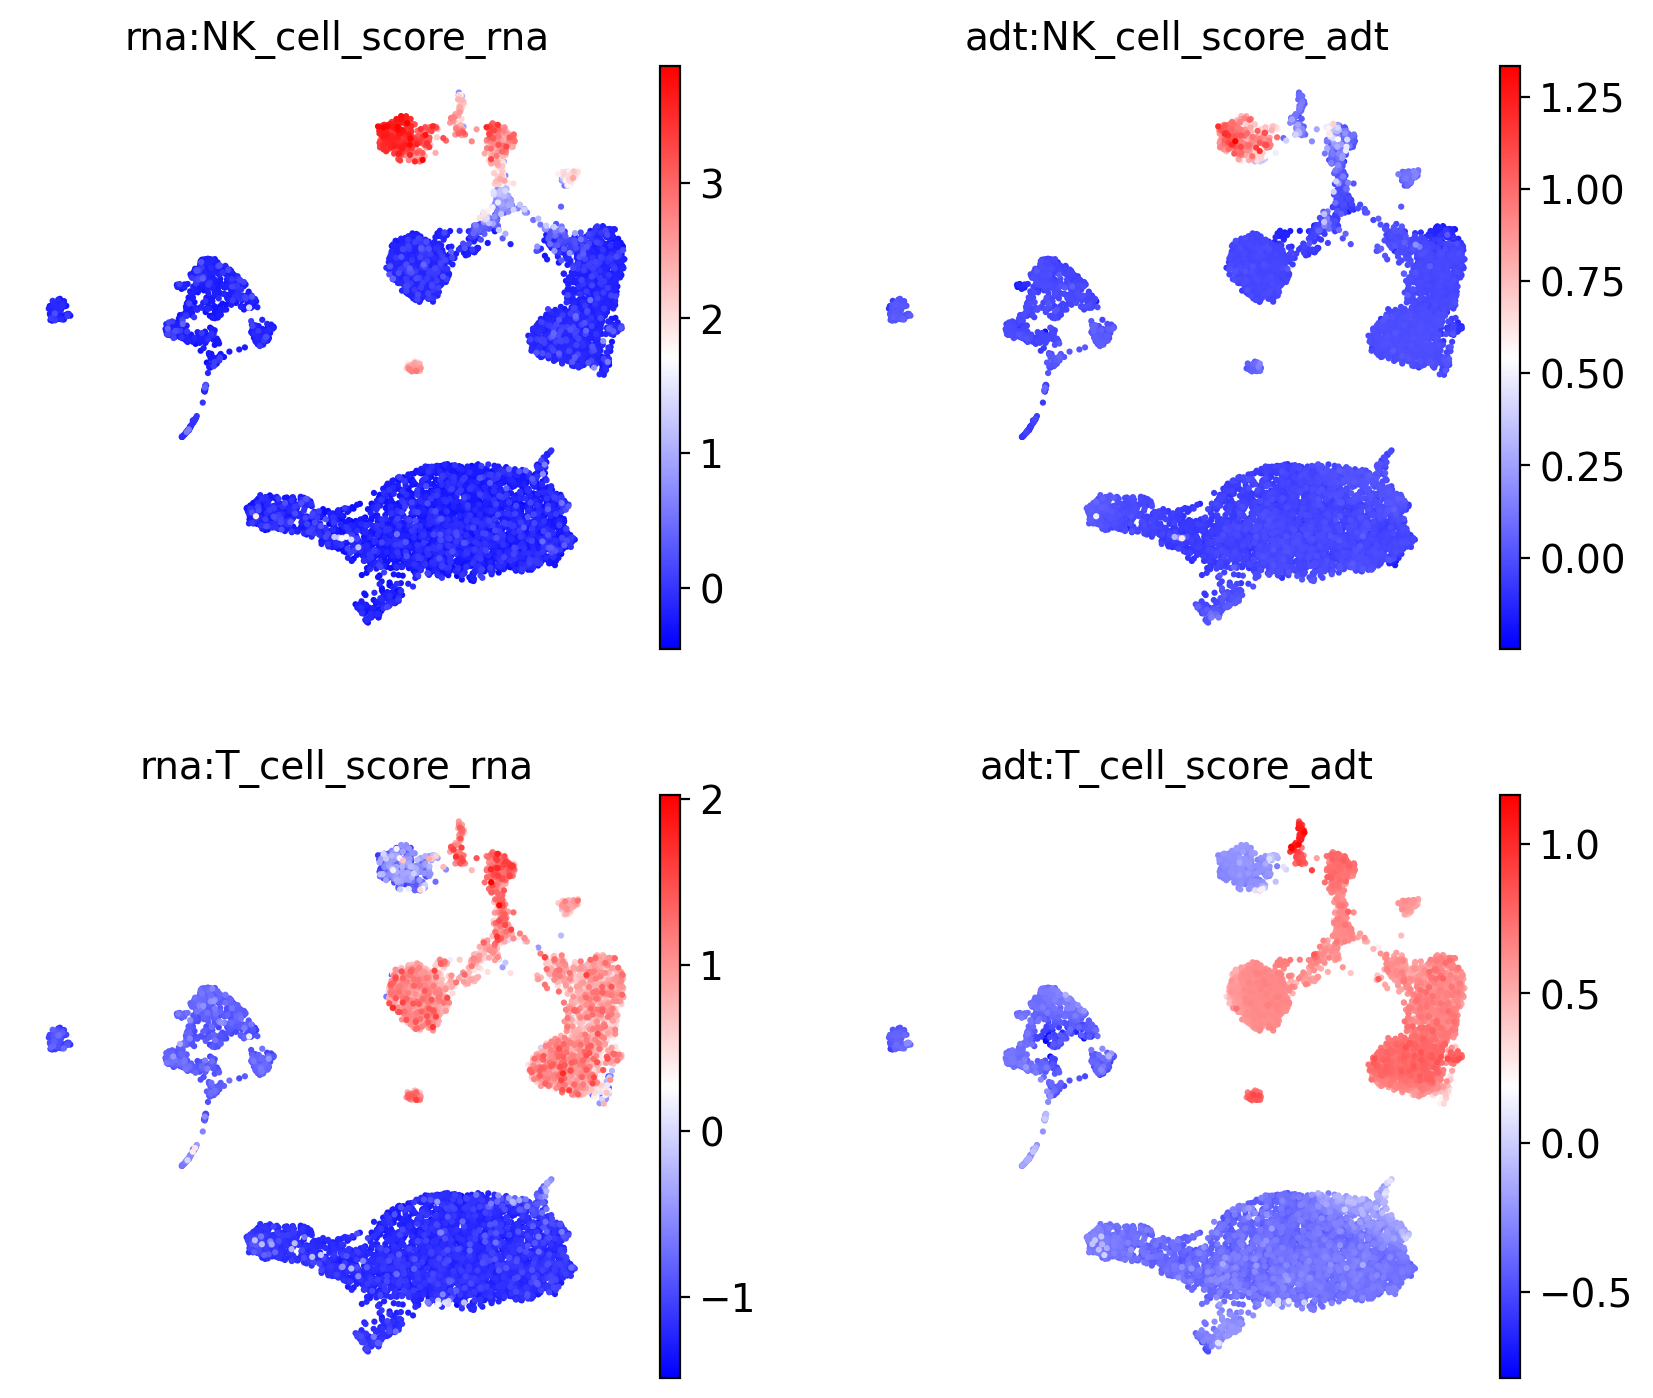

In [28]:
# Make NK cell score based on imputed proteins
score_3 = 'NK_cell_score_adt'
markers = ['adt_CD56-1_pred', 'adt_CD56-2_pred', 'adt_CD158b_pred', 'adt_CD158_pred', 'adt_CD335_pred']
sc.tl.score_genes(mdata.mod['adt'], markers, score_name = score_3)

# Make T cell score based on imputed proteins
score_4 = 'T_cell_score_adt'
markers = ['adt_CD3-1_pred','adt_CD3-2_pred']
sc.tl.score_genes(mdata.mod['adt'], markers, score_name = score_4)
mdata.update()

# Visualize scores
sc.pl.umap(
    mdata, 
    color = ['rna:' + score_1, # RNA based NK score
             'adt:' + score_3, # ADT based NK score
             'rna:' + score_2, # RNA based T score
             'adt:' + score_4  # ADT based T score
            ], 
    cmap = "bwr", 
    frameon = False,
    s = 20,
    ncols = 2
)

(1.9432822660113076, 0.8913467700323818)

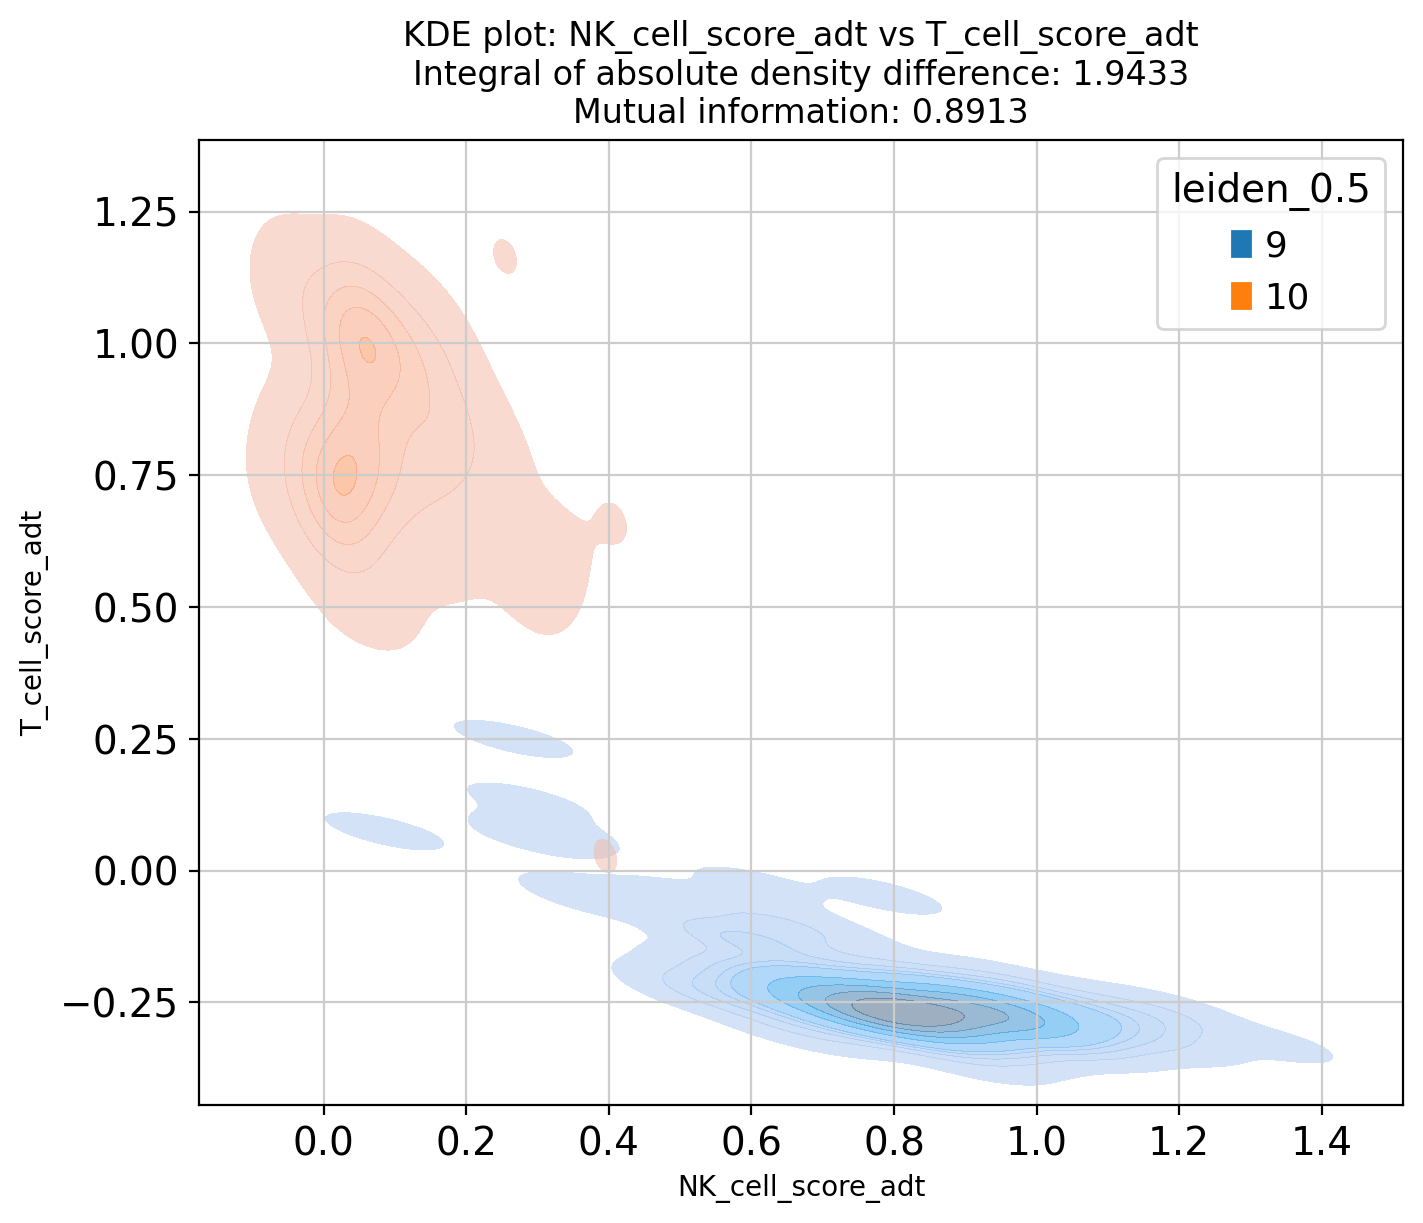

In [29]:
for i in ['adt', 'rna']:
    mdata.obs[f'T_cell_score_{i}'] = mdata.mod['adt'].obs[f'T_cell_score_{i}']
    mdata.obs[f'NK_cell_score_{i}'] = mdata.mod['adt'].obs[f'NK_cell_score_{i}']

scparadise.scnoah.clust_diff(
    mdata,
    groupby = 'leiden_0.5',
    group1 = '9',
    group2 = '10',
    score1 = 'NK_cell_score_adt',
    score2 = 'T_cell_score_adt'
)

The KDE plot also shows almost no overlap between 10 and 9 clusters based on NK and T scores calculated using imputed surface protein data. <br>

Integral of absolute density difference increased from 1.7856 to 1.9433. <br>

Mutual information increased from 0.5497 to 0.8913. <br>

Each metric follows the principle that the higher the value, the better the clusters separate the selected scores.

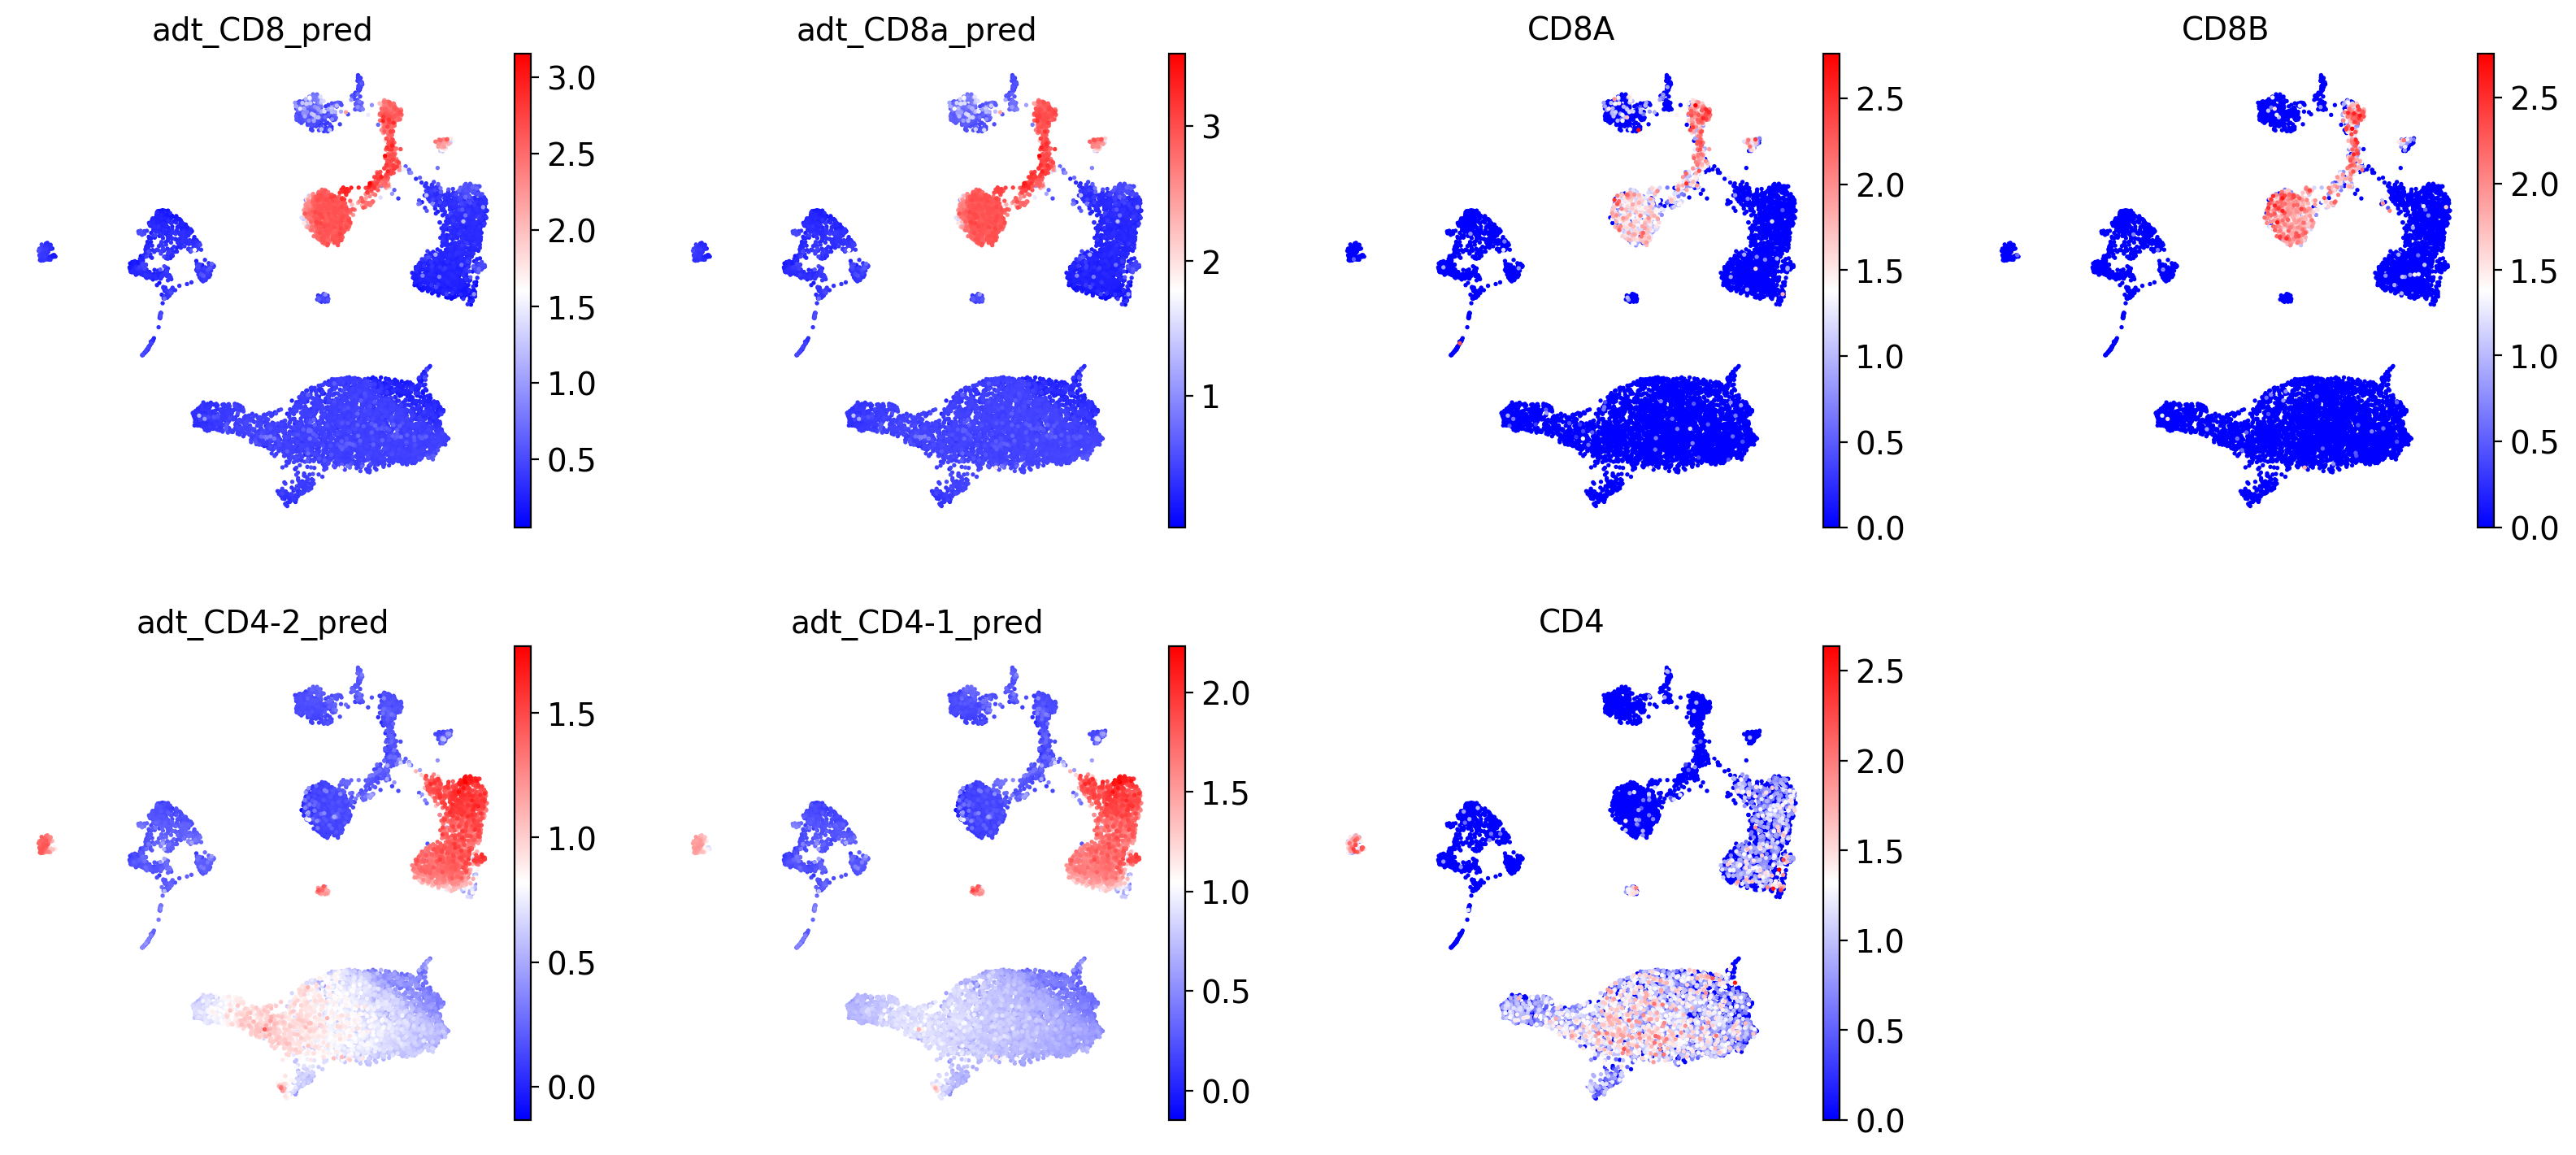

In [30]:
# Visualize RNA and ADT markers of T cell subtypes
mu.pl.umap(
    mdata, 
    color = [
        'adt_CD8_pred', 
        'adt_CD8a_pred',
        'CD8A',
        'CD8B',
        'adt_CD4-2_pred', 
        'adt_CD4-1_pred',
        'CD4'
    ],
    frameon = False,
    cmap = 'bwr',
    ncols = 4
)

## Imputed surface proteins facilitates cell type annotation

In [31]:
# Marker genes
markers_dict = {
    "B": ["CD79A", "MS4A1", 'adt_CD19_pred', 'adt_CD20_pred'],
    "plasmacytoid DC": ["IRF7", "IRF8", 'adt_CD304_pred', 'adt_CD303_pred'],
    "classical DC": ["FCER1A", "adt_CD1c_pred"],
    "CD14+ Monocytes": ["CD14", 'adt_CD14_pred'],
    "CD16+ Monocytes": ["FCGR3A", 'adt_CD16_pred'],
    "NK": ["GNLY", "NKG7", 'adt_CD56-1_pred', 'adt_CD56-2_pred'],
    "CD4 T": ["CD4", 'adt_CD4-1_pred', 'adt_CD4-2_pred'],
    "CD8 T": ["CD8A", 'CD8B', 'adt_CD8_pred', 'adt_CD8a_pred',],
    "Platelet": ["PPBP", 'PF4'],
    "HSPC": ['CD34', 'GATA2', 'adt_CD34_pred']
}

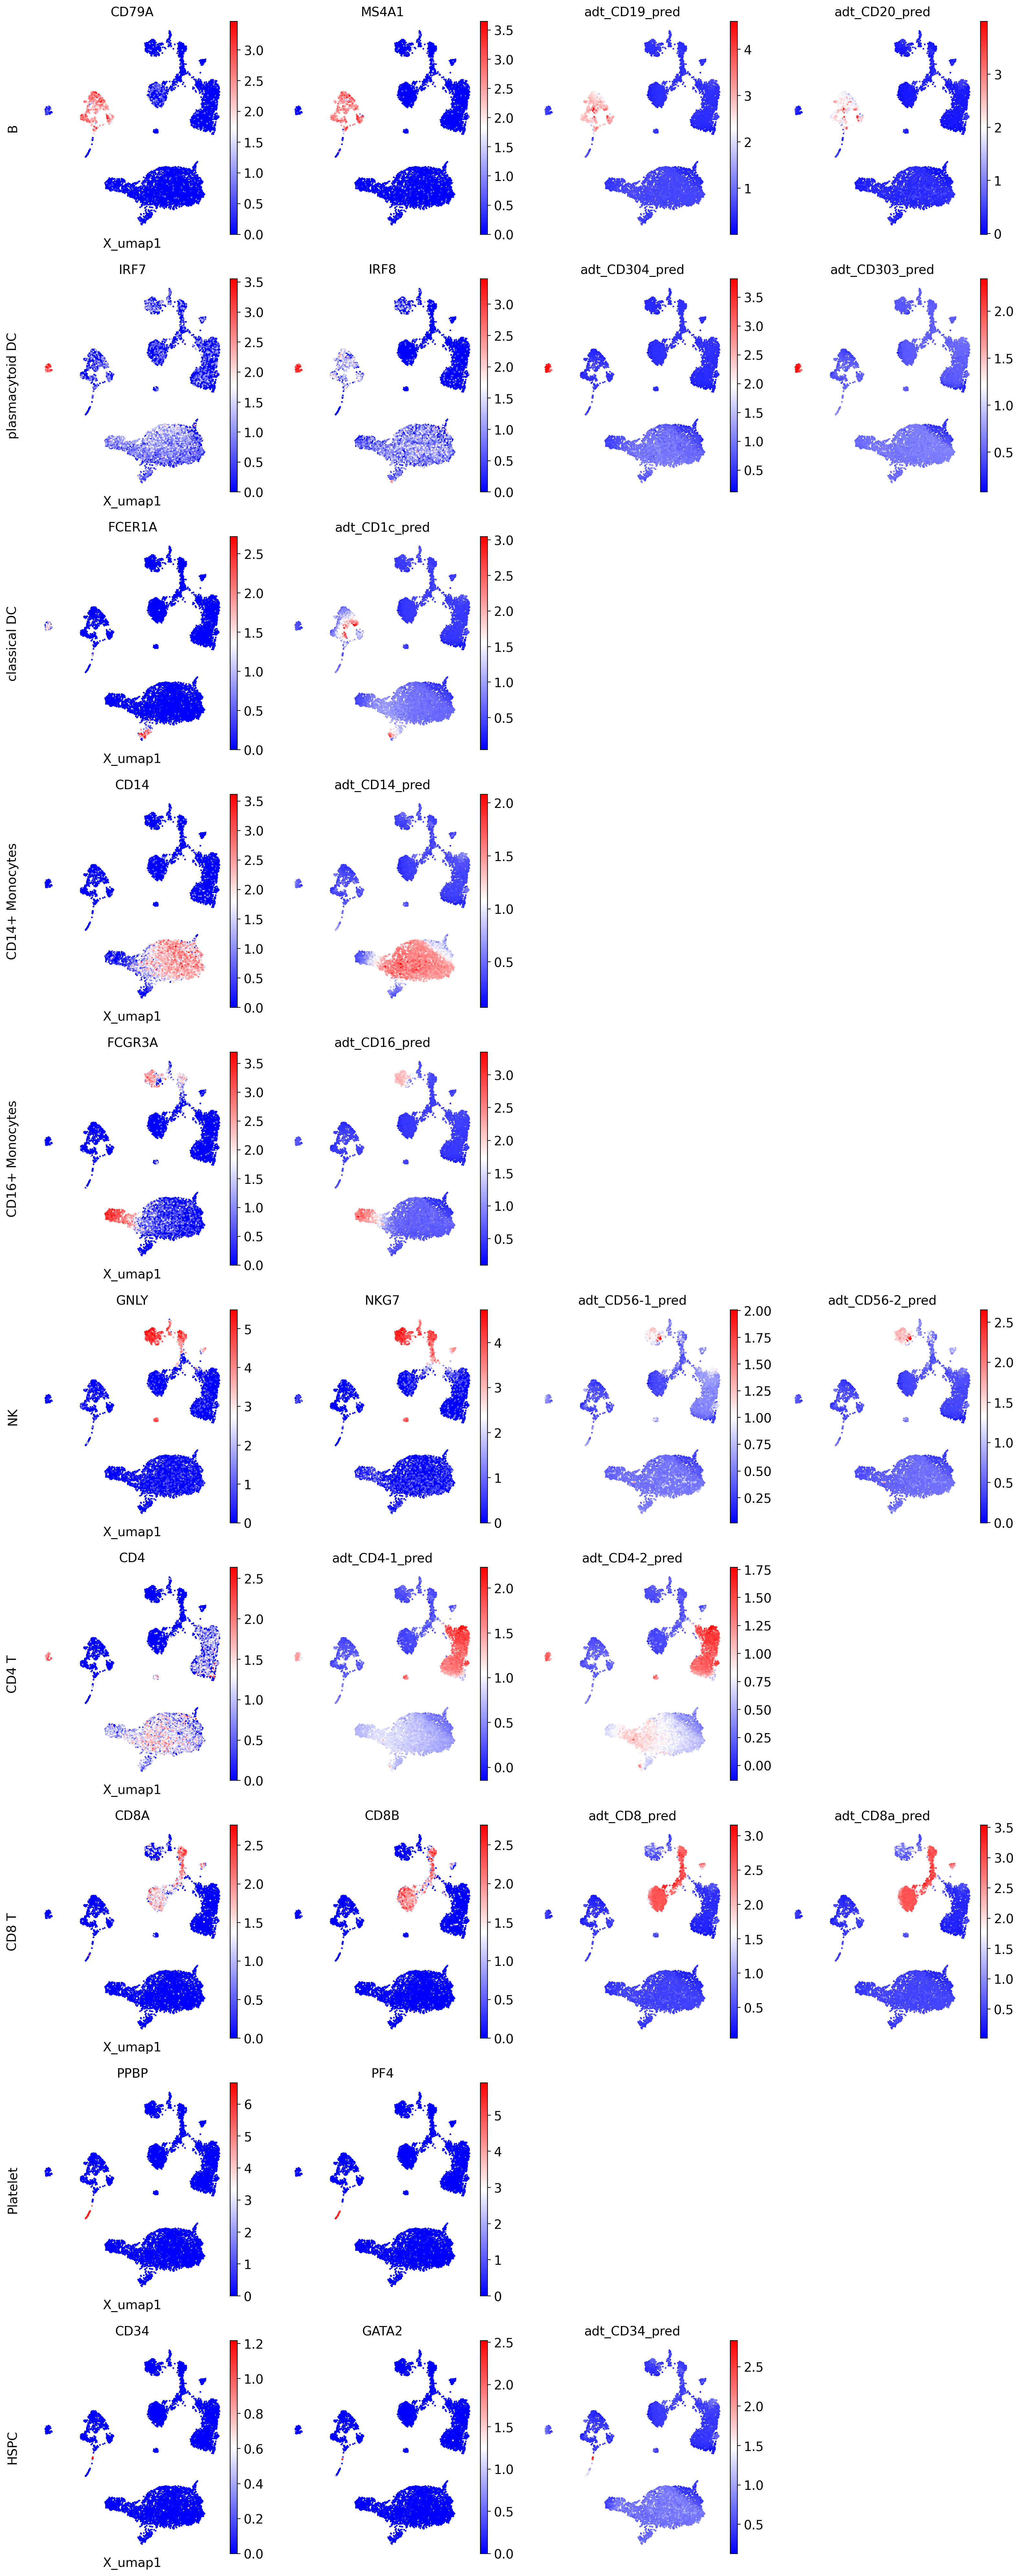

In [32]:
# Make Axes
# Number of needed rows and columns (based on the row with the most columns)
nrow = len(markers_dict)
ncol = max([len(vs) for vs in markers_dict.values()])
fig, axs = plt.subplots(nrow, ncol, figsize=(4 * ncol, 4 * nrow))
# Plot expression for every marker on the corresponding Axes object
for row_idx, (cell_type, markers) in enumerate(markers_dict.items()):
    col_idx = 0
    for marker in markers:
        ax = axs[row_idx, col_idx]
        mu.pl.umap(
            mdata, 
            color=marker, 
            ax=ax, 
            show=False, 
            frameon=False, 
            cmap = 'bwr'
        )
        # Add cell type as row label - here we simply add it as ylabel of
        # the first Axes object in the row
        if col_idx == 0:
            # We disabled axis drawing in UMAP to have plots without background and border
            # so we need to re-enable axis to plot the ylabel
            ax.axis("on")
            ax.tick_params(
                top="off",
                bottom="off",
                left="off",
                right="off",
                labelleft="on",
                labelbottom="off",
            )
            ax.set_ylabel(cell_type + "\n", rotation=90, fontsize=14)
            ax.set(frame_on=False)
        col_idx += 1
    # Remove unused column Axes in the current row
    while col_idx < ncol:
        axs[row_idx, col_idx].remove()
        col_idx += 1
# Alignment within the Figure
fig.tight_layout()

In [33]:
mdata.write_h5mu('pbmc_mdata.h5mu')

In [34]:
import session_info2
session_info2.session_info()

Package,Version
pandas,2.3.3
scanpy,1.11.5
scparadise,1.2.0
muon,0.1.7
numpy,2.4.3
matplotlib,3.10.8
anndata,0.12.10
mudata,0.3.3
Component,Info
Python,"3.11.15 (main, Mar 11 2026, 17:20:07) [GCC 14.3.0]"
